# Notebook 3 – Porto Seguro Safe Driver Prediction (Classification)

## Overview
We benchmark five tabular-learning methods on the Porto Seguro dataset:
**Tabular ResNet**, **FT-Transformer**, **XGBoost**, **LightGBM**, and **Random Forest**.  
Each model is tuned with **Optuna** (20 trials) and evaluated across 3 seeds.  
Metrics: **Accuracy**, **AUC-ROC**, **PR-AUC** , **F1**.

> **Note:** The dataset is heavily imbalanced (~3.6 % positives). PR-AUC provides a better metric for imbalanced datasets
> as it is designed to focus specifically on the positive, typically rarer class, which is much more informative.


In [48]:
# Package installation (uncomment if running in a new environment)
# !pip install rtdl_revisiting_models optuna xgboost lightgbm scikit-learn pandas numpy matplotlib seaborn shap

## Imports

In [49]:
import warnings
warnings.filterwarnings('ignore')
import time

import random, os, zipfile, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

import rtdl_revisiting_models
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import xgboost as xgb
import lightgbm as lgb
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, average_precision_score
from sklearn.model_selection import train_test_split

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

torch.backends.cudnn.benchmark = True
print(f"cudnn.benchmark  = {torch.backends.cudnn.benchmark}")

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"


Using device: cuda
cudnn.benchmark  = True


## Configuration
These parameters denote the key parameters for the experiments.
- SEEDS: Set 3 specific seed numbers
- N_OPTUNA_TRIALS: Number of trials to run for Optuna hyperparameter tuning
- TEST_SIZE: Proportion of data used for train-test split
- VAL_FRAC: Proportion of training data divided into train-validation (effectively 60/20/20 for train/val/test split)
- N_PATIENCE: Number of trials for early stopping when validation performance stops improving
- OPT_EPOCHS: Number of epochs to run for Optuna hyperparameter tuning
- FT_EPOCHS: Number of epochs to run when training across seeds

In [50]:
SEEDS           = [42, 123, 456]
N_OPTUNA_TRIALS = 20
TEST_SIZE       = 0.20
VAL_FRAC        = 0.25
N_PATIENCE      = 10
OPT_EPOCHS      = 50
FT_EPOCHS       = 100

## Data Loading

In [51]:
# Create data directory and load the dataset
os.makedirs('data/porto_seguro', exist_ok=True)
df = None
zip_path = 'data/porto-seguro-safe-driver-prediction.zip'

try:
    # Open the existing ZIP file and extract
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall('data/porto_seguro')

    # Load the training CSV directly
    csv_path = 'data/porto_seguro/train.csv'
    df = pd.read_csv(csv_path)
    print(f"Loaded training data: {df.shape}")

    # Load the test CSV directly
    test_csv_path = 'data/porto_seguro/test.csv'
    df_test = pd.read_csv(test_csv_path)
    print(f"Loaded test data: {df_test.shape}")

except Exception as e:
    print(f"Failed to read from local ZIP: {e}")
    print("Please make sure the file exists at:")
    print(zip_path)
    df = None
    df_test = None

Loaded training data: (595212, 59)
Loaded test data: (892816, 58)


## Exploratory Data Analysis (EDA)

In [52]:
print("Shape:", df.shape)
print()
print("Target distribution:")
print(df['target'].value_counts())
print(f"Positive rate: {df['target'].mean():.3%}")

Shape: (595212, 59)

Target distribution:
target
0    573518
1     21694
Name: count, dtype: int64
Positive rate: 3.645%


In the train and test data, features that belong to similar groupings are tagged as such in the feature names (e.g., ind, reg, car, calc). In addition, feature names include the postfix bin to indicate binary features and cat to indicate categorical features. Features without these designations are either continuous or ordinal.

In [53]:
# Check for categorical and numerical columns
df.columns

Index(['id', 'target', 'ps_ind_01', 'ps_ind_02_cat', 'ps_ind_03',
       'ps_ind_04_cat', 'ps_ind_05_cat', 'ps_ind_06_bin', 'ps_ind_07_bin',
       'ps_ind_08_bin', 'ps_ind_09_bin', 'ps_ind_10_bin', 'ps_ind_11_bin',
       'ps_ind_12_bin', 'ps_ind_13_bin', 'ps_ind_14', 'ps_ind_15',
       'ps_ind_16_bin', 'ps_ind_17_bin', 'ps_ind_18_bin', 'ps_reg_01',
       'ps_reg_02', 'ps_reg_03', 'ps_car_01_cat', 'ps_car_02_cat',
       'ps_car_03_cat', 'ps_car_04_cat', 'ps_car_05_cat', 'ps_car_06_cat',
       'ps_car_07_cat', 'ps_car_08_cat', 'ps_car_09_cat', 'ps_car_10_cat',
       'ps_car_11_cat', 'ps_car_11', 'ps_car_12', 'ps_car_13', 'ps_car_14',
       'ps_car_15', 'ps_calc_01', 'ps_calc_02', 'ps_calc_03', 'ps_calc_04',
       'ps_calc_05', 'ps_calc_06', 'ps_calc_07', 'ps_calc_08', 'ps_calc_09',
       'ps_calc_10', 'ps_calc_11', 'ps_calc_12', 'ps_calc_13', 'ps_calc_14',
       'ps_calc_15_bin', 'ps_calc_16_bin', 'ps_calc_17_bin', 'ps_calc_18_bin',
       'ps_calc_19_bin', 'ps_calc_20_bin'],


In [54]:
# Print the number of unique values in each column to check for high-cardinality features
print("Number of unique values in each column:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()}")

Number of unique values in each column:
id: 595212
target: 2
ps_ind_01: 8
ps_ind_02_cat: 5
ps_ind_03: 12
ps_ind_04_cat: 3
ps_ind_05_cat: 8
ps_ind_06_bin: 2
ps_ind_07_bin: 2
ps_ind_08_bin: 2
ps_ind_09_bin: 2
ps_ind_10_bin: 2
ps_ind_11_bin: 2
ps_ind_12_bin: 2
ps_ind_13_bin: 2
ps_ind_14: 5
ps_ind_15: 14
ps_ind_16_bin: 2
ps_ind_17_bin: 2
ps_ind_18_bin: 2
ps_reg_01: 10
ps_reg_02: 19
ps_reg_03: 5013
ps_car_01_cat: 13
ps_car_02_cat: 3
ps_car_03_cat: 3
ps_car_04_cat: 10
ps_car_05_cat: 3
ps_car_06_cat: 18
ps_car_07_cat: 3
ps_car_08_cat: 2
ps_car_09_cat: 6
ps_car_10_cat: 3
ps_car_11_cat: 104
ps_car_11: 5
ps_car_12: 184
ps_car_13: 70482
ps_car_14: 850
ps_car_15: 15
ps_calc_01: 10
ps_calc_02: 10
ps_calc_03: 10
ps_calc_04: 6
ps_calc_05: 7
ps_calc_06: 11
ps_calc_07: 10
ps_calc_08: 11
ps_calc_09: 8
ps_calc_10: 26
ps_calc_11: 20
ps_calc_12: 11
ps_calc_13: 14
ps_calc_14: 24
ps_calc_15_bin: 2
ps_calc_16_bin: 2
ps_calc_17_bin: 2
ps_calc_18_bin: 2
ps_calc_19_bin: 2
ps_calc_20_bin: 2


Values of -1 indicate that the feature was missing from the observation.

In [55]:
# -1 values as missing indicator
n_neg1 = (df == -1).sum()
print("Columns with -1 (missing values):")
print(n_neg1[n_neg1 > 0])

Columns with -1 (missing values):
ps_ind_02_cat       216
ps_ind_04_cat        83
ps_ind_05_cat      5809
ps_reg_03        107772
ps_car_01_cat       107
ps_car_02_cat         5
ps_car_03_cat    411231
ps_car_05_cat    266551
ps_car_07_cat     11489
ps_car_09_cat       569
ps_car_11             5
ps_car_12             1
ps_car_14         42620
dtype: int64


Check for collinearity to remove confounding variables if necessary.

In [56]:
# Find columns with high collinearity
corr_matrix = df.drop(columns=['id', 'target']).corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
collinear_pairs = [
    (col, row, upper_tri.loc[row, col])
    for col in upper_tri.columns
    for row in upper_tri.index
    if upper_tri.loc[row, col] > 0.9
]

if not collinear_pairs:
    print("No highly correlated column pairs found (corr > 0.9).")
else:
    print("Highly correlated column pairs (corr > 0.9):")
    for pair in collinear_pairs:
        print(f"{pair[0]} - {pair[1]} : {pair[2]:.2f}")


No highly correlated column pairs found (corr > 0.9).


## Preprocessing

In [57]:
# Extract target variable and drop id column
df_proc = df.drop(columns=['id']).copy()
y = df_proc['target'].values.astype(np.int64)
df_feat = df_proc.drop(columns=['target'])

# Identify categorical and numerical columns
cat_cols_ps  = [c for c in df_feat.columns if c.endswith('_cat')]
num_cols_ps  = [c for c in df_feat.columns if c not in cat_cols_ps]

print(f"Numerical features: {len(num_cols_ps)}")
print(f"Categorical features: {len(cat_cols_ps)}")

# Replace -1 with NaN
df_feat[cat_cols_ps] = df_feat[cat_cols_ps].replace(-1, np.nan)
df_feat[num_cols_ps] = df_feat[num_cols_ps].replace(-1, np.nan)

# Impute using mode for categorical and median for numerical
for col in cat_cols_ps:
    mode_val = df_feat[col].mode()
    if len(mode_val) > 0:
        df_feat[col] = df_feat[col].fillna(mode_val[0])
    else:
        df_feat[col] = df_feat[col].fillna(0)

for col in num_cols_ps:
    df_feat[col] = df_feat[col].fillna(df_feat[col].median())

print("Missing values after imputation:", df_feat.isnull().sum().sum())

Numerical features: 43
Categorical features: 14
Missing values after imputation: 0


In [58]:
# Data preprocessing for classical models - xgboost, lightgbm, random forest, logistics regression
# Perform one-hot encoding for categorical variables and standard scaling for numerical variables

# Find columns with high cardinality > 50 and drop them
max_cardinality = 50 
cat_cardinalities = df_feat[cat_cols_ps].nunique()
cat_cols_filtered = [col for col in cat_cols_ps if cat_cardinalities[col] <= max_cardinality]

print("Dropped high-cardinality columns:", [col for col in cat_cols_ps if col not in cat_cols_filtered])
print("Kept categorical columns:", cat_cols_filtered)

# One-hot encode the filtered categorical columns
onehot_enc_ps = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_cat_ohe = onehot_enc_ps.fit_transform(df_feat[cat_cols_filtered].astype(str)).astype(np.float32)

# Scale numerical variables
scaler_ps = StandardScaler()
X_num_ps = scaler_ps.fit_transform(df_feat[num_cols_ps].values.astype(np.float32))

# Combine: numerical (scaled) + OHE categorical (binary floats)
X_all_ps = np.concatenate([X_num_ps, X_cat_ohe], axis=1)

Dropped high-cardinality columns: ['ps_car_11_cat']
Kept categorical columns: ['ps_ind_02_cat', 'ps_ind_04_cat', 'ps_ind_05_cat', 'ps_car_01_cat', 'ps_car_02_cat', 'ps_car_03_cat', 'ps_car_04_cat', 'ps_car_05_cat', 'ps_car_06_cat', 'ps_car_07_cat', 'ps_car_08_cat', 'ps_car_09_cat', 'ps_car_10_cat']


In [73]:
# Data preprocessing for deep learning models - ResNet, FT-Transformer
# Perform ordinal encoding for categorical variables and standard scaling for numerical variables

ord_enc = OrdinalEncoder(
    handle_unknown='use_encoded_value',
    unknown_value=-1
)

X_cat_ord = ord_enc.fit_transform(df_feat[cat_cols_ps].astype(str)).astype(np.int64)
X_num_ps = scaler_ps.fit_transform(df_feat[num_cols_ps].values.astype(np.float32))

#  Drop high-cardinality categorical columns
max_cardinality = 50
cat_cardinalities = df_feat[cat_cols_ps].nunique()
high_card_cols = [col for col in cat_cols_ps if cat_cardinalities[col] > max_cardinality]
keep_cat_idx = [i for i, col in enumerate(cat_cols_ps) if col not in high_card_cols]

X_cat_ord = X_cat_ord[:, keep_cat_idx]
cat_cards_ps = [len(cats) for i, cats in enumerate(ord_enc.categories_) if cat_cols_ps[i] not in high_card_cols]
n_num_ps = X_num_ps.shape[1]   # number of numerical columns

# Combine numerical + categorical
X_all_dl = np.concatenate([X_num_ps, X_cat_ord.astype(np.float32)], axis=1)

print("X_all shape:", X_all_dl.shape)
print(f"Numerical: {n_num_ps}, Ordinal categorical: {X_cat_ord.shape[1]}")
print("Categorical cardinalities (for embedding):", cat_cards_ps)

X_all shape: (595212, 56)
Numerical: 43, Ordinal categorical: 13
Categorical cardinalities (for embedding): [4, 2, 7, 12, 2, 2, 10, 2, 18, 2, 2, 5, 3]


## Data Splitting (60 / 20 / 20)

In [60]:
idx = np.arange(len(y))
idx_tv, idx_test = train_test_split(idx, test_size=TEST_SIZE, random_state=42, stratify=y)
idx_train, idx_val = train_test_split(idx_tv, test_size=VAL_FRAC, random_state=42,
                                       stratify=y[idx_tv])

# Classical model splits (numerical + OHE categorical)
X_tr_all, X_v_all, X_te_all = X_all_ps[idx_train], X_all_ps[idx_val], X_all_ps[idx_test]

# Deep learning splits: separate numerical and ordinal-encoded categorical (for embeddings)
X_tr_num = X_num_ps[idx_train]
X_v_num  = X_num_ps[idx_val]
X_te_num = X_num_ps[idx_test]

X_tr_cat = X_cat_ord[idx_train]
X_v_cat  = X_cat_ord[idx_val]
X_te_cat = X_cat_ord[idx_test]

y_train_ps, y_val_ps, y_test_ps = y[idx_train], y[idx_val], y[idx_test]

sc_ps = StandardScaler()
X_tr_sc = sc_ps.fit_transform(X_tr_all)
X_v_sc  = sc_ps.transform(X_v_all)
X_te_sc = sc_ps.transform(X_te_all)

spw = float((y_train_ps == 0).sum()) / float((y_train_ps == 1).sum())
print(f"Classical - Train: {X_tr_all.shape}, Val: {X_v_all.shape}, Test: {X_te_all.shape}")
print(f"DL num  - Train: {X_tr_num.shape}, Val: {X_v_num.shape}, Test: {X_te_num.shape}")
print(f"DL cat  - Train: {X_tr_cat.shape}, Val: {X_v_cat.shape}, Test: {X_te_cat.shape}")
print(f"scale_pos_weight = {spw:.2f}")

Classical - Train: (357126, 114), Val: (119043, 114), Test: (119043, 114)
DL num  - Train: (357126, 43), Val: (119043, 43), Test: (119043, 43)
DL cat  - Train: (357126, 13), Val: (119043, 13), Test: (119043, 13)
scale_pos_weight = 26.44


## Helper Functions

In [61]:
def set_seed(seed):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
 
 
def compute_porto_metrics(y_true, y_pred, y_prob):
    from sklearn.metrics import accuracy_score, roc_auc_score, f1_score
    acc  = accuracy_score(y_true, y_pred)
    auc  = roc_auc_score(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    return acc, auc, pr_auc, f1
 
 
def train_ft_transformer(
        model, X_num_tr, X_cat_tr, y_tr,
        X_num_v,  X_cat_v,  y_v,
        lr=1e-3, n_epochs=100, n_patience=10, batch_size=256,
        val_batch_size=512,
        task='regression', device_='cpu',
        use_amp=True, use_class_weight=False,
        timer=None):

    model = model.to(device_)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)

    if task == 'regression':
        criterion = nn.MSELoss()
    elif use_class_weight:
        pos_weight = float((y_tr == 0).sum()) / float((y_tr == 1).sum())
        criterion = nn.BCEWithLogitsLoss(
            pos_weight=torch.tensor([pos_weight], dtype=torch.float32, device=device_)
        )
    else:
        criterion = nn.BCEWithLogitsLoss()

    _amp_on = use_amp and device_ != 'cpu' and torch.cuda.is_available()
    scaler  = torch.amp.GradScaler(device=device_, enabled=_amp_on)

    # ── All data stays on CPU; batches are moved to GPU as needed ─────────
    X_num_tr_t = torch.FloatTensor(X_num_tr)
    X_cat_tr_t = torch.LongTensor(X_cat_tr)  if X_cat_tr is not None else None
    y_tr_t     = torch.FloatTensor(y_tr.astype(np.float32))
    X_num_v_t  = torch.FloatTensor(X_num_v)
    X_cat_v_t  = torch.LongTensor(X_cat_v)   if X_cat_v  is not None else None
    y_v_t      = torch.FloatTensor(y_v.astype(np.float32))

    train_losses, val_losses = [], []
    best_val   = float('inf')
    best_state = None           # stored on CPU to save GPU headroom
    patience   = n_patience
    pat_cnt    = 0

    for epoch in range(n_epochs):
        model.train()
        n = len(X_num_tr_t)
        idx_e = torch.randperm(n)

        ep_loss = 0.0
        for i in range(0, n, batch_size):
            b = idx_e[i : i + batch_size]
            xn = X_num_tr_t[b].to(device_, non_blocking=True)
            xc = X_cat_tr_t[b].to(device_, non_blocking=True) \
                 if X_cat_tr_t is not None else None
            yb = y_tr_t[b].to(device_, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            if timer: timer.start("forward")
            with torch.amp.autocast(device_, enabled=_amp_on):
                out  = model(xn, xc).squeeze(-1)
                loss = criterion(out, yb)
            if timer: timer.stop("forward")

            if timer: timer.start("backward")
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            if timer: timer.stop("backward")

            ep_loss += loss.item() * len(b)

        # ── BATCHED validation ─────────────────────────────────────────────
        model.eval()
        val_loss_acc = 0.0
        n_v = len(X_num_v_t)
        with torch.no_grad():
            if timer: timer.start("validation")
            for j in range(0, n_v, val_batch_size):
                xn_v = X_num_v_t[j : j + val_batch_size].to(device_, non_blocking=True)
                xc_v = (X_cat_v_t[j : j + val_batch_size].to(device_, non_blocking=True)
                        if X_cat_v_t is not None else None)
                yb_v = y_v_t[j : j + val_batch_size].to(device_, non_blocking=True)
                with torch.amp.autocast(device_, enabled=_amp_on):
                    vout = model(xn_v, xc_v).squeeze(-1)
                    val_loss_acc += criterion(vout, yb_v).item() * len(xn_v)
            if timer: timer.stop("validation")
        vloss = val_loss_acc / n_v

        train_losses.append(ep_loss / n)
        val_losses.append(vloss)

        if vloss < best_val:
            best_val   = vloss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            pat_cnt    = 0
        else:
            pat_cnt += 1
        if pat_cnt >= patience:
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, train_losses, val_losses
 
 
def predict_ft_transformer(model, X_num, X_cat, device_, batch_size=512):
    """Batched inference — same memory budget as training."""
    model.eval()
    model   = model.to(device_)
    X_num_t = torch.FloatTensor(X_num)
    X_cat_t = torch.LongTensor(X_cat) if X_cat is not None else None
    _amp_on = device_ != 'cpu' and torch.cuda.is_available()
    preds   = []
    with torch.no_grad():
        for i in range(0, len(X_num_t), batch_size):
            xn = X_num_t[i : i + batch_size].to(device_, non_blocking=True)
            xc = (X_cat_t[i : i + batch_size].to(device_, non_blocking=True)
                  if X_cat_t is not None else None)
            with torch.amp.autocast(device_, enabled=_amp_on):
                out = model(xn, xc).squeeze(-1)
            preds.append(out.cpu().numpy())
    return np.concatenate(preds)
 

# Phase timer

class PhaseTimer:
    def __init__(self):
        self._totals = {}
        self._counts = {}
        self._start = {}

    def start(self, phase):
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        self._start[phase] = time.perf_counter()

    def stop(self, phase):
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        elapsed = time.perf_counter() - self._start[phase]
        self._totals[phase] = self._totals.get(phase, 0.0) + elapsed
        self._counts[phase] = self._counts.get(phase, 0) + 1

    def get_total(self, phase):
        return self._totals.get(phase, 0.0)

    def reset(self):
        self._totals.clear()
        self._counts.clear()
        self._start.clear()

    def report(self, label=''):
        total = sum(self._totals.values())
        print(f"\n--- Bottleneck Report {label} ---")
        for k, v in sorted(self._totals.items(), key=lambda x: -x[1]):
            pct = 100 * v / total if total > 0 else 0.0
            avg = 1000 * v / self._counts[k]
            print(f"{k:<20} {v:.3f}s ({pct:.1f}%) avg {avg:.2f} ms")
        print(f"TOTAL: {total:.3f}s\n")


## Model 1: Tabular ResNet

In [62]:
from rtdl_revisiting_models import ResNet as _RTDLResNet


class TabularResNet(nn.Module):
    """RTDL ResNet backbone with learned categorical embeddings.

    Numerical features are fed directly; categorical features are passed
    through per-feature nn.Embedding layers and concatenated with the
    numerical block before entering the RTDL ResNet.
    """
    def __init__(self, n_num_features, cat_cardinalities, d_embedding=16,
                 n_blocks=3, d_block=128, d_hidden=256,
                 dropout1=0.1, dropout2=0.0):
        super().__init__()

        self.has_cat = cat_cardinalities is not None and len(cat_cardinalities) > 0
        if self.has_cat:
            self.cat_embeddings = nn.ModuleList([
                nn.Embedding(cardinality, d_embedding)
                for cardinality in cat_cardinalities
            ])
            cat_dim = len(cat_cardinalities) * d_embedding
        else:
            self.cat_embeddings = None
            cat_dim = 0

        d_in = n_num_features + cat_dim

        self.resnet = _RTDLResNet(
            d_in=d_in,
            d_out=1,
            n_blocks=n_blocks,
            d_block=d_block,
            d_hidden=d_hidden,
            d_hidden_multiplier=None,
            dropout1=dropout1,
            dropout2=dropout2,
        )

    def forward(self, x_num, x_cat=None):
        if self.has_cat and x_cat is not None:
            cat_embs = [emb(x_cat[:, i]) for i, emb in enumerate(self.cat_embeddings)]
            x = torch.cat([x_num] + cat_embs, dim=1)
        else:
            x = x_num
        return self.resnet(x)


n_num_rn = X_tr_num.shape[1]

print(f"TabularResNet input: {n_num_rn} numerical + {X_tr_cat.shape[1]} categorical features")
print(f"  Numerical  - Train: {X_tr_num.shape}, Val: {X_v_num.shape}, Test: {X_te_num.shape}")
print(f"  Categorical - Train: {X_tr_cat.shape}, Val: {X_v_cat.shape}, Test: {X_te_cat.shape}")
print(f"  Cardinalities: {cat_cards_ps}")


TabularResNet input: 43 numerical + 13 categorical features
  Numerical  - Train: (357126, 43), Val: (119043, 43), Test: (119043, 43)
  Categorical - Train: (357126, 13), Val: (119043, 13), Test: (119043, 13)
  Cardinalities: [4, 2, 7, 12, 2, 2, 10, 2, 18, 2, 2, 5, 3]


In [63]:
all_results    = []
timing_results = []

timer = PhaseTimer()


def resnet_porto_objective(trial):
    d_embedding = trial.suggest_categorical('d_embedding', [8, 16, 24, 32])
    d_block     = trial.suggest_categorical('d_block',     [64, 128, 256])
    n_blocks    = trial.suggest_int('n_blocks', 1, 4)
    d_hidden    = trial.suggest_categorical('d_hidden',    [128, 256, 512])
    dropout1    = trial.suggest_float('dropout1', 0.0, 0.5)
    dropout2    = trial.suggest_float('dropout2', 0.0, 0.5)
    lr          = trial.suggest_float('lr', 1e-4, 1e-3, log=True)

    set_seed(42)

    model = TabularResNet(
        n_num_features=n_num_rn,
        cat_cardinalities=cat_cards_ps,
        d_embedding=d_embedding,
        n_blocks=n_blocks,
        d_block=d_block,
        d_hidden=d_hidden,
        dropout1=dropout1,
        dropout2=dropout2,
    )

    model, _, _ = train_ft_transformer(
        model,
        X_tr_num, X_tr_cat, y_train_ps,
        X_v_num,  X_v_cat,  y_val_ps,
        lr=lr, n_epochs=50, n_patience=N_PATIENCE, batch_size=1024,
        task='classification', device_=str(device),
        use_class_weight=True,
    )

    raw   = predict_ft_transformer(model, X_v_num, X_v_cat, str(device))
    prob  = torch.sigmoid(torch.tensor(raw)).numpy()
    score = average_precision_score(y_val_ps, prob)

    print(f"Trial {trial.number}: "
          f"d_emb={d_embedding}, d_block={d_block}, n_blocks={n_blocks}, "
          f"d_hidden={d_hidden}, dropout1={dropout1:.3f}, dropout2={dropout2:.3f}, "
          f"lr={lr:.5f} => PR-AUC={score:.5f}")

    return score


timer.start("optuna")

study_rn = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42),
)
study_rn.optimize(resnet_porto_objective, n_trials=N_OPTUNA_TRIALS)

timer.stop("optuna")

optuna_time = timer.get_total("optuna")

best_rn = study_rn.best_params
print("\nBest TabularResNet params:")
print(best_rn)


Trial 0: d_emb=16, d_block=64, n_blocks=4, d_hidden=256, dropout1=0.485, dropout2=0.416, lr=0.00016 => PR-AUC=0.06272
Trial 1: d_emb=32, d_block=256, n_blocks=1, d_hidden=512, dropout1=0.393, dropout2=0.100, lr=0.00033 => PR-AUC=0.06072
Trial 2: d_emb=24, d_block=256, n_blocks=4, d_hidden=512, dropout1=0.220, dropout2=0.061, lr=0.00031 => PR-AUC=0.06235
Trial 3: d_emb=16, d_block=256, n_blocks=1, d_hidden=128, dropout1=0.447, dropout2=0.299, lr=0.00084 => PR-AUC=0.06239
Trial 4: d_emb=32, d_block=256, n_blocks=2, d_hidden=256, dropout1=0.401, dropout2=0.037, lr=0.00097 => PR-AUC=0.06256
Trial 5: d_emb=32, d_block=256, n_blocks=1, d_hidden=512, dropout1=0.312, dropout2=0.165, lr=0.00012 => PR-AUC=0.06043
Trial 6: d_emb=24, d_block=64, n_blocks=3, d_hidden=512, dropout1=0.247, dropout2=0.261, lr=0.00027 => PR-AUC=0.06195
Trial 7: d_emb=32, d_block=256, n_blocks=1, d_hidden=256, dropout1=0.038, dropout2=0.145, lr=0.00014 => PR-AUC=0.06104
Trial 8: d_emb=8, d_block=256, n_blocks=3, d_hidde

In [68]:
print("Trials done:", len(study_rn.trials))
print("Best PR-AUC:", study_rn.best_value)
print("Best params:", study_rn.best_params)

Trials done: 20
Best PR-AUC: 0.06298088158596973
Best params: {'d_embedding': 16, 'd_block': 128, 'n_blocks': 3, 'd_hidden': 128, 'dropout1': 0.41914608991240354, 'dropout2': 0.35572505634766016, 'lr': 0.00045974508866670864}


In [69]:
print("\nTraining TabularResNet across seeds...")
rn_train_curves = {}

for seed in SEEDS:
    set_seed(seed)

    model = TabularResNet(
        n_num_features=n_num_rn,
        cat_cardinalities=cat_cards_ps,
        d_embedding=best_rn['d_embedding'],
        n_blocks=best_rn['n_blocks'],
        d_block=best_rn['d_block'],
        d_hidden=best_rn['d_hidden'],
        dropout1=best_rn['dropout1'],
        dropout2=best_rn['dropout2'],
    )

    # TRAINING
    timer.start("train")

    model, tr_l, va_l = train_ft_transformer(
        model,
        X_tr_num, X_tr_cat, y_train_ps,
        X_v_num,  X_v_cat,  y_val_ps,
        lr=best_rn['lr'], n_epochs=100, n_patience=N_PATIENCE, batch_size=1024,
        task='classification', device_=str(device),
        use_class_weight=True,
        timer=timer,
    )

    timer.stop("train")

    rn_train_curves[seed] = (tr_l, va_l)

    # --- Threshold tuning on validation ---
    val_raw  = predict_ft_transformer(model, X_v_num, X_v_cat, str(device))
    val_prob = torch.sigmoid(torch.tensor(val_raw)).numpy()
    thresholds = np.linspace(0.01, 0.99, 99)
    f1_scores  = [f1_score(y_val_ps, (val_prob >= t).astype(int)) for t in thresholds]
    best_t     = thresholds[np.argmax(f1_scores)]

    # INFERENCE
    timer.start("inference")

    raw  = predict_ft_transformer(model, X_te_num, X_te_cat, str(device))
    prob = torch.sigmoid(torch.tensor(raw)).numpy()

    timer.stop("inference")

    pred = (prob >= best_t).astype(int)

    acc, auc, pr_auc, f1 = compute_porto_metrics(y_test_ps, pred, prob)

    all_results.append({
        'method': 'TabularResNet', 'seed': seed,
        'accuracy': acc, 'auc': auc, 'pr_auc': pr_auc, 'f1': f1
    })

    print(f"  Seed {seed}: Acc={acc:.4f}, AUC={auc:.4f}, PR-AUC={pr_auc:.4f}, "
          f"F1={f1:.4f} (thr={best_t:.2f})")



Training TabularResNet across seeds...
  Seed 42: Acc=0.8524, AUC=0.6337, PR-AUC=0.0620, F1=0.1114 (thr=0.61)
  Seed 123: Acc=0.8597, AUC=0.6339, PR-AUC=0.0625, F1=0.1121 (thr=0.62)
  Seed 456: Acc=0.8603, AUC=0.6333, PR-AUC=0.0627, F1=0.1127 (thr=0.62)


In [72]:
# Save the model size and print it
torch.save(model.state_dict(), 'porto_tabular_resnet.pth')
print("Model size on disk: {:.2f} MB".format(os.path.getsize('porto_tabular_resnet.pth') / (1024 * 1024)))

Model size on disk: 0.53 MB


In [70]:
train_time     = timer.get_total("train")
inference_time = timer.get_total("inference")

timing_results.append({
    "method":         "TabularResNet",
    "optuna_time":    optuna_time,
    "train_time":     train_time,
    "inference_time": inference_time,
})


In [71]:
timer.report("TabularResNet")



--- Bottleneck Report TabularResNet ---
optuna               1065.144s (60.1%) avg 1065144.38 ms
train                352.620s (19.9%) avg 70523.96 ms
backward             190.939s (10.8%) avg 5.19 ms
forward              107.448s (6.1%) avg 2.92 ms
validation           53.579s (3.0%) avg 515.18 ms
inference            2.066s (0.1%) avg 413.28 ms
TOTAL: 1771.796s



### Breakdown of time report
- optuna (1065s, 60.1%): This is the hyperparameter search phase. Optuna runs multiple trials to find the best configuration. It dominates the total time because it’s exploring many candidate models.
- train (352s, 19.9%): The actual training loop for the final/best model across seeds. This includes forward passes, backward passes, and validation checks.
- backward (190s, 10.8%) avg 5.19 ms: Time spent computing gradients via backpropagation. The average per batch backward pass took ~5 ms.
- forward (107s, 6.1%) avg 2.92 ms: Time spent on the forward pass (model inference during training). Each batch forward pass took ~3 ms.
- validation (53s, 3.0%) avg 515 ms: Time spent evaluating on the validation set after each epoch. Average validation run took ~0.5 seconds.
- inference (2s, 0.1%) avg 413 ms: Time spent on final test inference. Each inference batch took ~0.4 seconds.
- TOTAL: 1771s (~29.5 minutes): Sum of all phases.

## Model 2: FT-Transformer

In [74]:
torch.cuda.empty_cache()

In [75]:
def _cleanup_gpu(study, trial):
    """Optuna callback: free GPU cache after every trial."""
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()
 
 
def ft_porto_objective(trial):
    d_block   = trial.suggest_categorical('d_block',           [64, 128])
    n_blocks  = trial.suggest_int        ('n_blocks',           1, 3)
    attn_heads= trial.suggest_categorical('attention_n_heads',  [2, 4])
    ffn_mult  = trial.suggest_float      ('ffn_d_hidden_multiplier', 1.0, 1.5)
    attn_drop = trial.suggest_float      ('attention_dropout',  0.0, 0.3)
    ffn_drop  = trial.suggest_float      ('ffn_dropout',        0.0, 0.3)
    lr        = trial.suggest_float      ('lr', 1e-4, 5e-4, log=True)
 
    set_seed(42)
 
    model = rtdl_revisiting_models.FTTransformer(
        n_cont_features      = n_num_ps,
        cat_cardinalities    = cat_cards_ps,
        d_block              = d_block,
        n_blocks             = n_blocks,
        attention_n_heads    = attn_heads,
        ffn_d_hidden_multiplier = ffn_mult,
        attention_dropout    = attn_drop,
        ffn_dropout          = ffn_drop,
        residual_dropout     = 0.0,
        d_out                = 1,
    )
 
    model, _, _ = train_ft_transformer(
        model, X_tr_num, X_tr_cat, y_train_ps,
        X_v_num,  X_v_cat,  y_val_ps,
        lr             = lr,
        n_epochs       = 50,
        n_patience     = N_PATIENCE,
        batch_size     = 256,
        val_batch_size = 512,
        task           = 'classification',
        device_        = str(device),
    )
 
    raw  = predict_ft_transformer(model, X_v_num, X_v_cat, str(device), batch_size=512)
    prob = torch.sigmoid(torch.tensor(raw)).numpy()
    score = average_precision_score(y_val_ps, prob)

    # Log trial details
    print(f"Trial {trial.number + 1} → PR-AUC: {score:.4f}")

    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()

    return score
 
 
# Clean slate, then run
torch.cuda.empty_cache(); gc.collect()
 
study_ft = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42),
)
study_ft.optimize(
    ft_porto_objective,
    n_trials       = N_OPTUNA_TRIALS,
    catch          = (torch.cuda.OutOfMemoryError,),  # skip OOM trials gracefully
    callbacks      = [_cleanup_gpu],
    gc_after_trial = True,
)
 
best_ft = study_ft.best_params
print("Trials done:", len(study_ft.trials))
print("Best PR-AUC:", study_ft.best_value)
print(f"Best FT-Transformer params: {best_ft}")

Trial 1 → PR-AUC: 0.0637


[W 2026-04-14 23:28:02,799] Trial 1 failed with parameters: {'d_block': 64, 'n_blocks': 3, 'attention_n_heads': 2, 'ffn_d_hidden_multiplier': 1.0909124836035504, 'attention_dropout': 0.055021352956030146, 'ffn_dropout': 0.09127267288786131, 'lr': 0.0002326960468194962} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "c:\Users\cs_no\Envs\DSS5104\lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "C:\Users\cs_no\AppData\Local\Temp\ipykernel_18172\3794439374.py", line 32, in ft_porto_objective
    model, _, _ = train_ft_transformer(
  File "C:\Users\cs_no\AppData\Local\Temp\ipykernel_18172\1073442779.py", line 79, in train_ft_transformer
    scaler.scale(loss).backward()
  File "c:\Users\cs_no\Envs\DSS5104\lib\site-packages\torch\_tensor.py", line 624, in backward
    torch.autograd.backward(
  File "c:\Users\cs_no\Envs\DSS5104\lib\site-packages\torch\autograd\__init__.py", line 347,

KeyboardInterrupt: 

In [ ]:
print("Training FT-Transformer across seeds...")
ft_train_curves = {}
 
for seed in SEEDS:
    del model
    torch.cuda.empty_cache(); gc.collect()
    set_seed(seed)
 
    model = rtdl_revisiting_models.FTTransformer(
        n_cont_features         = n_num_ps,
        cat_cardinalities       = cat_cards_ps,
        d_block                 = best_ft['d_block'],
        n_blocks                = best_ft['n_blocks'],
        attention_n_heads       = best_ft['attention_n_heads'],
        ffn_d_hidden_multiplier = best_ft['ffn_d_hidden_multiplier'],
        attention_dropout       = best_ft['attention_dropout'],
        ffn_dropout             = best_ft['ffn_dropout'],
        residual_dropout        = 0.0,
        d_out                   = 1,
    )
 
    model, tr_l, va_l = train_ft_transformer(
        model, X_tr_num, X_tr_cat, y_train_ps,
        X_v_num,  X_v_cat,  y_val_ps,
        lr             = best_ft['lr'],
        n_epochs       = 100,
        n_patience     = N_PATIENCE,
        batch_size     = 256,
        val_batch_size = 512,
        task           = 'classification',
        device_        = str(device)
    )
    ft_train_curves[seed] = (tr_l, va_l)
 
    # --- Threshold tuning on validation ---
    val_raw  = predict_ft_transformer(model, X_v_num, X_v_cat, str(device), batch_size=512)
    val_prob = torch.sigmoid(torch.tensor(val_raw)).numpy()
    thresholds = np.linspace(0.01, 0.5, 49)
    f1_scores = [f1_score(y_val_ps, (val_prob >= t).astype(int)) for t in thresholds]
    best_t = thresholds[np.argmax(f1_scores)]
 
    # --- Apply best threshold to test ---
    start = time.perf_counter()
    raw  = predict_ft_transformer(model, X_te_num, X_te_cat, str(device), batch_size=512)
    prob = torch.sigmoid(torch.tensor(raw)).numpy()
    pred = (prob >= best_t).astype(int)
    end = time.perf_counter()

    batch_latency = end - start
    per_sample_latency = batch_latency / len(X_te_num)

    acc, auc, pr_auc, f1 = compute_porto_metrics(y_test_ps, pred, prob)
    all_results.append({
        'method': 'FT-Transformer', 'seed': seed,
        'accuracy': acc, 'auc': auc, 'pr_auc': pr_auc, 'f1': f1,
        'threshold': best_t,
    })
    print(f"  Seed {seed}: Acc={acc:.4f}, AUC={auc:.4f}, PR-AUC={pr_auc:.4f}, F1={f1:.4f} (thr={best_t:.2f}), batch latency={batch_latency:.2f}s, per-sample latency={per_sample_latency:.4f}s")
 


Training FT-Transformer across seeds...
  Seed 42: Acc=0.8761, AUC=0.6365, PR-AUC=0.0657, F1=0.1168 (thr=0.06)
  Seed 123: Acc=0.8646, AUC=0.6361, PR-AUC=0.0636, F1=0.1131 (thr=0.06)
  Seed 456: Acc=0.8799, AUC=0.6369, PR-AUC=0.0650, F1=0.1163 (thr=0.06)


In [ ]:
# Save the model size and print it
torch.save(model.state_dict(), 'porto_ft_transformer.pth')
print("Model size on disk: {:.2f} MB".format(os.path.getsize('porto_ft_transformer.pth') / (1024 * 1024)))

## Model 3: XGBoost

In [ ]:
def xgb_porto_objective(trial):
    params = {
        'n_estimators':    trial.suggest_int('n_estimators', 100, 500),
        'max_depth':       trial.suggest_int('max_depth', 3, 8),
        'learning_rate':   trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':       trial.suggest_float('subsample', 0.6, 1.0),
        'scale_pos_weight': spw,
        'random_state':    42
    }
    set_seed(42)
    m = xgb.XGBClassifier(**params, verbosity=0, use_label_encoder=False,
                           eval_metric='auc')
    m.fit(X_tr_all, y_train_ps)
    prob = m.predict_proba(X_v_all)[:, 1]
    return average_precision_score(y_val_ps, prob)

study_xgb = optuna.create_study(direction='maximize',
                                  sampler=optuna.samplers.TPESampler(seed=42))
study_xgb.optimize(xgb_porto_objective, n_trials=N_OPTUNA_TRIALS)
best_xgb = study_xgb.best_params

print("Trials done:", len(study_xgb.trials))
print("Best PR-AUC:", study_xgb.best_value)
print(f"Best XGBoost params: {best_xgb}")

Best XGBoost params: {'n_estimators': 439, 'max_depth': 4, 'learning_rate': 0.025789192592501852, 'subsample': 0.651483988078596}


In [ ]:
print("Training XGBoost across seeds...")
xgb_model_last = None
for seed in SEEDS:
    set_seed(seed)
    m = xgb.XGBClassifier(**best_xgb, scale_pos_weight=spw,
                           random_state=seed, verbosity=0,
                           use_label_encoder=False, eval_metric='auc')
    m.fit(X_tr_all, y_train_ps)
    start = time.perf_counter()
    preds = m.predict(X_te_all)
    probs = m.predict_proba(X_te_all)[:, 1]
    end = time.perf_counter()

    batch_latency = end - start
    per_sample_latency = batch_latency / len(X_te_all)

    acc, auc, pr_auc, f1 = compute_porto_metrics(y_test_ps, preds, probs)
    all_results.append({'method': 'XGBoost', 'seed': seed,
                        'accuracy': acc, 'auc': auc, 'pr_auc': pr_auc, 'f1': f1})
    xgb_model_last = m
    print(f"  Seed {seed}: Acc={acc:.4f}, AUC={auc:.4f}, PR-AUC={pr_auc:.4f}, F1={f1:.4f}, batch latency={batch_latency:.2f}s, per-sample latency={per_sample_latency:.4f}s")

# Save the last trained XGBoost model and print its size
xgb_model_last.save_model("porto_xgb.json")
print("XGBoost model size on disk: {:.2f} MB".format(os.path.getsize("porto_xgb.json") / (1024 * 1024)))

Training XGBoost across seeds...
  Seed 42: Acc=0.6431, AUC=0.6402, PR-AUC=0.0659, F1=0.1014
  Seed 123: Acc=0.6435, AUC=0.6385, PR-AUC=0.0652, F1=0.1013
  Seed 456: Acc=0.6428, AUC=0.6389, PR-AUC=0.0654, F1=0.1015


## Model 4: LightGBM

In [ ]:
def lgb_porto_objective(trial):
    params = {
        'n_estimators':  trial.suggest_int('n_estimators', 100, 500),
        'num_leaves':    trial.suggest_int('num_leaves', 20, 150),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'random_state':  42, 'verbose': -1, 'is_unbalance': True
    }
    m = lgb.LGBMClassifier(**params)
    m.fit(X_tr_all, y_train_ps)
    prob = m.predict_proba(X_v_all)[:, 1]
    return average_precision_score(y_val_ps, prob)

study_lgb = optuna.create_study(direction='maximize',
                                  sampler=optuna.samplers.TPESampler(seed=42))
study_lgb.optimize(lgb_porto_objective, n_trials=N_OPTUNA_TRIALS)
best_lgb = study_lgb.best_params

print("Trials done:", len(study_lgb.trials))
print("Best PR-AUC:", study_lgb.best_value)
print(f"Best LightGBM params: {best_lgb}")


Best LightGBM params: {'n_estimators': 482, 'num_leaves': 20, 'learning_rate': 0.010260022325256595}


In [ ]:
print("Training LightGBM across seeds...")
lgb_model_last = None
for seed in SEEDS:
    set_seed(seed)
    m = lgb.LGBMClassifier(**best_lgb, random_state=seed, verbose=-1,
                            is_unbalance=True)
    m.fit(X_tr_all, y_train_ps)

    start = time.perf_counter()
    preds = m.predict(X_te_all)
    probs = m.predict_proba(X_te_all)[:, 1]
    end = time.perf_counter()

    batch_latency = end - start
    per_sample_latency = batch_latency / len(X_te_all)
    
    acc, auc, pr_auc, f1 = compute_porto_metrics(y_test_ps, preds, probs)
    all_results.append({'method': 'LightGBM', 'seed': seed,
                        'accuracy': acc, 'auc': auc, 'pr_auc': pr_auc, 'f1': f1})
    lgb_model_last = m
    print(f"  Seed {seed}: Acc={acc:.4f}, AUC={auc:.4f}, PR-AUC={pr_auc:.4f}, F1={f1:.4f}, batch latency={batch_latency:.2f}s, per-sample latency={per_sample_latency:.4f}s ")

# Save the last trained LightGBM model and print its size
lgb_model_last.booster_.save_model("porto_lgb.txt")
print("LightGBM model size on disk: {:.2f} MB".format(os.path.getsize("porto_lgb.txt") / (1024 * 1024)))

Training LightGBM across seeds...
  Seed 42: Acc=0.6316, AUC=0.6383, PR-AUC=0.0653, F1=0.1002
  Seed 123: Acc=0.6325, AUC=0.6382, PR-AUC=0.0652, F1=0.1000
  Seed 456: Acc=0.6311, AUC=0.6377, PR-AUC=0.0653, F1=0.0995


## Model 5: Random Forest

In [44]:
def rf_porto_objective(trial):
    params = {
        'n_estimators':    trial.suggest_int('n_estimators', 100, 500),
        'max_depth':       trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'random_state':    42
    }
    set_seed(42)
    m = RandomForestClassifier(**params, class_weight='balanced', n_jobs=-1)
    m.fit(X_tr_all, y_train_ps)
    prob = m.predict_proba(X_v_all)[:, 1]
    return average_precision_score(y_val_ps, prob)

study_rf = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=42))
study_rf.optimize(rf_porto_objective, n_trials=N_OPTUNA_TRIALS)
best_rf = study_rf.best_params
print(f"Best RF params: {best_rf}")


Best RF params: {'n_estimators': 239, 'max_depth': 8, 'min_samples_split': 11}


In [45]:
print("Trials done:", len(study_rf.trials))
print("Best PR-AUC:", study_rf.best_value)
print("Best params:", study_rf.best_params)

Trials done: 20
Best PR-AUC: 0.06123075122472118
Best params: {'n_estimators': 239, 'max_depth': 8, 'min_samples_split': 11}


In [ ]:
print("Training Random Forest across seeds...")
rf_model_last = None
for seed in SEEDS:
    set_seed(seed)
    m = RandomForestClassifier(**best_rf, random_state=seed,
                                class_weight='balanced', n_jobs=-1)
    m.fit(X_tr_all, y_train_ps)

    start = time.perf_counter()
    preds = m.predict(X_te_all)
    probs = m.predict_proba(X_te_all)[:, 1]
    end = time.perf_counter()
    
    batch_latency = end - start
    per_sample_latency = batch_latency / len(X_te_all)

    acc, auc, pr_auc, f1 = compute_porto_metrics(y_test_ps, preds, probs)
    all_results.append({'method': 'RandomForest', 'seed': seed,
                        'accuracy': acc, 'auc': auc, 'pr_auc': pr_auc, 'f1': f1})
    rf_model_last = m
    print(f"  Seed {seed}: Acc={acc:.4f}, AUC={auc:.4f}, PR-AUC={pr_auc:.4f}, F1={f1:.4f}, batch latency={batch_latency:.2f}s, per-sample latency={per_sample_latency:.4f}s ")

# Save the last trained Random Forest model and print its size
joblib.dump(rf_model_last, "porto_rf.joblib")
print("Random Forest model size on disk: {:.2f} MB".format(os.path.getsize("porto_rf.joblib") / (1024 * 1024)))

Training Random Forest across seeds...
  Seed 42: Acc=0.6608, AUC=0.6268, PR-AUC=0.0612, F1=0.0982
  Seed 123: Acc=0.6578, AUC=0.6267, PR-AUC=0.0608, F1=0.0979
  Seed 456: Acc=0.6550, AUC=0.6254, PR-AUC=0.0605, F1=0.0972


## Model 6: Logistic Regression

In [ ]:
def lr_porto_objective(trial):
    C = trial.suggest_float('C', 0.01, 10.0, log=True)
    class_weight = trial.suggest_categorical('class_weight', ['balanced', None])

    set_seed(42)
    model = LogisticRegression(
        C=C,
        penalty='l2',
        solver='liblinear',
        class_weight=class_weight,
        max_iter=1000,
        random_state=42
    )
    model.fit(X_tr_sc, y_train_ps)
    prob = model.predict_proba(X_v_sc)[:, 1]
    return average_precision_score(y_val_ps, prob)

study_lr = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=42))
study_lr.optimize(lr_porto_objective, n_trials=N_OPTUNA_TRIALS)
best_lr = study_lr.best_params
print("Best PR-AUC:", study_lr.best_value)
print(f"Best Logistic Regression params: {best_lr}")

print("Training Logistic Regression across seeds...")
lr_model_last = None
for seed in SEEDS:
    set_seed(seed)
    model = LogisticRegression(
        C=best_lr['C'],
        penalty='l2',
        solver='liblinear',
        class_weight=best_lr['class_weight'],
        max_iter=1000,
        random_state=seed
    )
    model.fit(X_tr_sc, y_train_ps)

    # --- Threshold tuning on validation ---
    val_prob = model.predict_proba(X_v_sc)[:, 1]
    thresholds = np.linspace(0.01, 0.50, 49)
    f1_scores = [f1_score(y_val_ps, (val_prob >= t).astype(int)) for t in thresholds]
    best_t = thresholds[np.argmax(f1_scores)]

    # --- Apply best threshold to test ---
    start = time.perf_counter()
    prob = model.predict_proba(X_te_sc)[:, 1]
    pred = (prob >= best_t).astype(int)
    end = time.perf_counter()

    batch_latency = end - start
    per_sample_latency = batch_latency / len(X_te_sc)

    acc, auc, pr_auc, f1 = compute_porto_metrics(y_test_ps, pred, prob)
    all_results.append({
        'method': 'LogisticRegression', 'seed': seed,
        'accuracy': acc, 'auc': auc, 'pr_auc': pr_auc, 'f1': f1, 'threshold': best_t
    })
    lr_model_last = model
    print(f"  Seed {seed}: Acc={acc:.4f}, AUC={auc:.4f}, PR-AUC={pr_auc:.4f}, F1={f1:.4f} (thr={best_t:.2f}), batch latency={batch_latency:.2f}s, per-sample latency={per_sample_latency:.4f}s")

## Results

In [47]:
df_res = pd.DataFrame(all_results)
summary = df_res.groupby('method').agg(
    acc_mean=('accuracy', 'mean'),  acc_std=('accuracy', 'std'),
    auc_mean=('auc', 'mean'),       auc_std=('auc', 'std'),
    pr_auc_mean=('pr_auc', 'mean'), pr_auc_std=('pr_auc', 'std'),
    f1_mean=('f1', 'mean'),         f1_std=('f1', 'std')
).round(4)

summary['Accuracy']      = summary['acc_mean'].astype(str)  + ' +/- ' + summary['acc_std'].astype(str)
summary['AUC-ROC']       = summary['auc_mean'].astype(str)  + ' +/- ' + summary['auc_std'].astype(str)
summary['PR-AUC']       = summary['pr_auc_mean'].astype(str)  + ' +/- ' + summary['pr_auc_std'].astype(str)
summary['F1']            = summary['f1_mean'].astype(str)   + ' +/- ' + summary['f1_std'].astype(str)
print(summary[['Accuracy', 'AUC-ROC', 'PR-AUC', 'F1']])


                         Accuracy  ...                 F1
method                             ...                   
FT-Transformer  0.8735 +/- 0.0079  ...   0.1154 +/- 0.002
LightGBM        0.6318 +/- 0.0007  ...  0.0999 +/- 0.0003
RandomForest    0.6578 +/- 0.0029  ...  0.0978 +/- 0.0005
TabularResNet   0.8642 +/- 0.0092  ...  0.1102 +/- 0.0013
XGBoost         0.6431 +/- 0.0004  ...  0.1014 +/- 0.0001

[5 rows x 4 columns]


## Visualizations

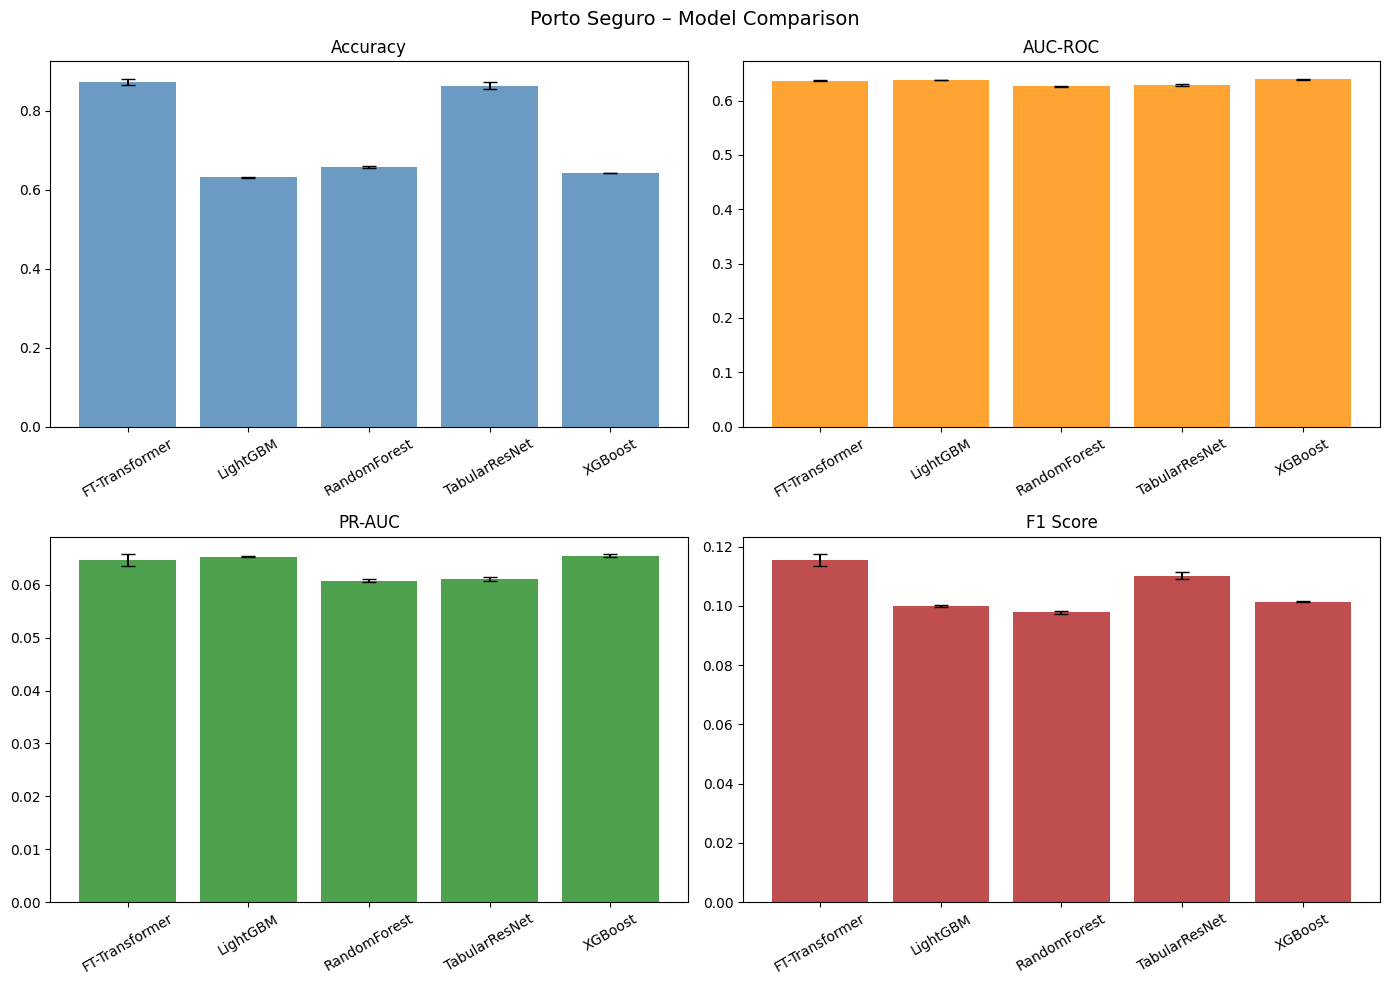

In [48]:
methods = summary.index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].bar(methods, summary['acc_mean'].values, yerr=summary['acc_std'].values,
               capsize=5, color='steelblue', alpha=0.8)
axes[0, 0].set_title('Accuracy')
axes[0, 0].tick_params(axis='x', rotation=30)

axes[0, 1].bar(methods, summary['auc_mean'].values, yerr=summary['auc_std'].values,
               capsize=5, color='darkorange', alpha=0.8)
axes[0, 1].set_title('AUC-ROC')
axes[0, 1].tick_params(axis='x', rotation=30)

axes[1, 0].bar(methods, summary['pr_auc_mean'].values, yerr=summary['pr_auc_std'].values,
               capsize=5, color='forestgreen', alpha=0.8)
axes[1, 0].set_title('PR-AUC')
axes[1, 0].tick_params(axis='x', rotation=30)

axes[1, 1].bar(methods, summary['f1_mean'].values, yerr=summary['f1_std'].values,
               capsize=5, color='firebrick', alpha=0.8)
axes[1, 1].set_title('F1 Score')
axes[1, 1].tick_params(axis='x', rotation=30)

plt.suptitle('Porto Seguro – Model Comparison', fontsize=14)
plt.tight_layout()
plt.show()


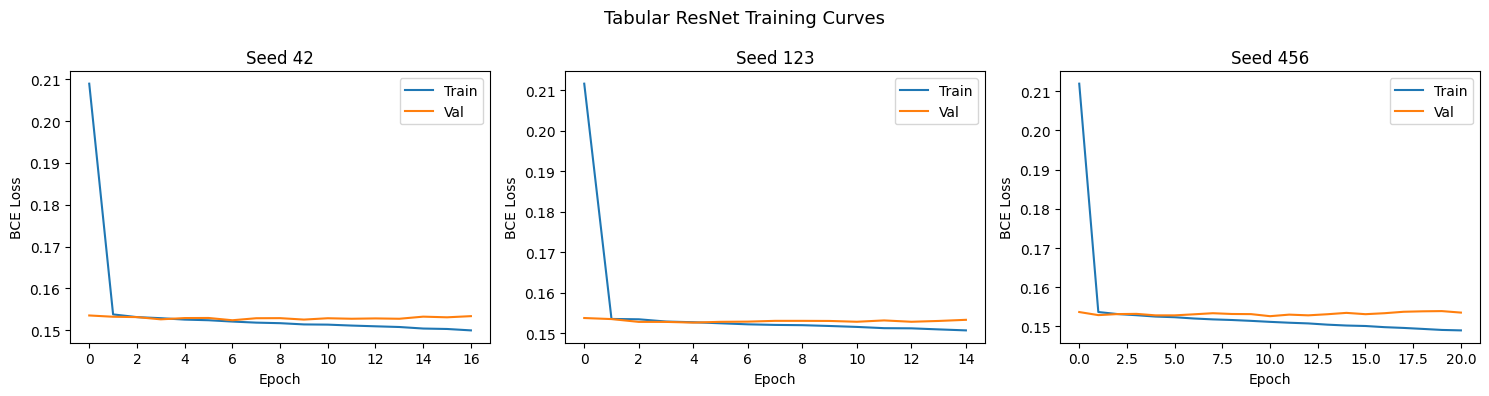

In [49]:
# Tabular ResNet training curves
fig, axes = plt.subplots(1, len(SEEDS), figsize=(15, 4))
for ax, seed in zip(axes, SEEDS):
    tr_l, va_l = rn_train_curves[seed]
    ax.plot(tr_l, label='Train')
    ax.plot(va_l, label='Val')
    ax.set_title(f'Seed {seed}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('BCE Loss')
    ax.legend()
plt.suptitle('Tabular ResNet Training Curves', fontsize=13)
plt.tight_layout()
plt.show()

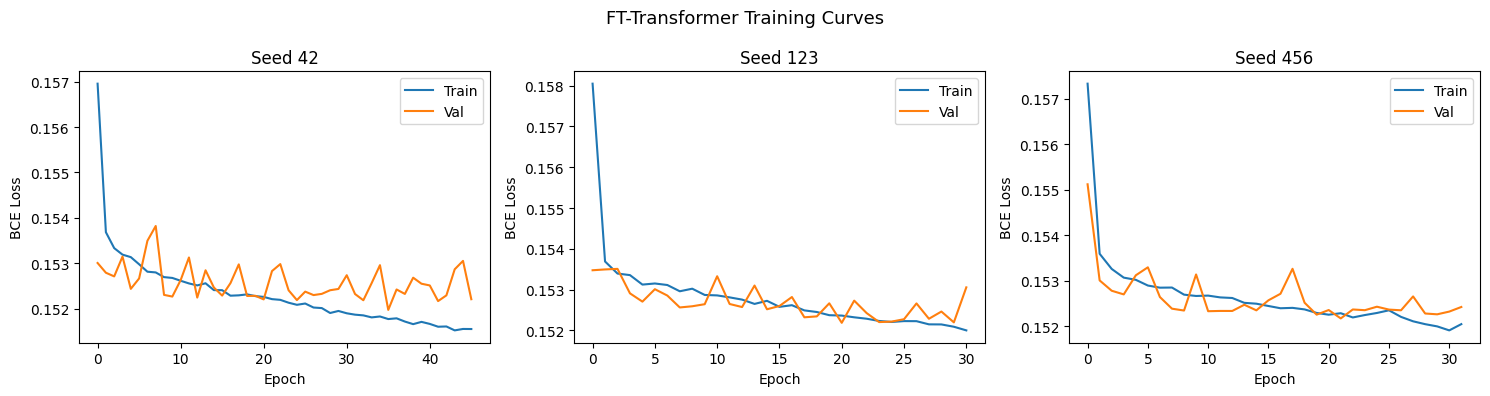

In [50]:
# FT-Transformer training curves
fig, axes = plt.subplots(1, len(SEEDS), figsize=(15, 4))
for ax, seed in zip(axes, SEEDS):
    tr_l, va_l = ft_train_curves[seed]
    ax.plot(tr_l, label='Train')
    ax.plot(va_l, label='Val')
    ax.set_title(f'Seed {seed}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('BCE Loss')
    ax.legend()
plt.suptitle('FT-Transformer Training Curves', fontsize=13)
plt.tight_layout()
plt.show()


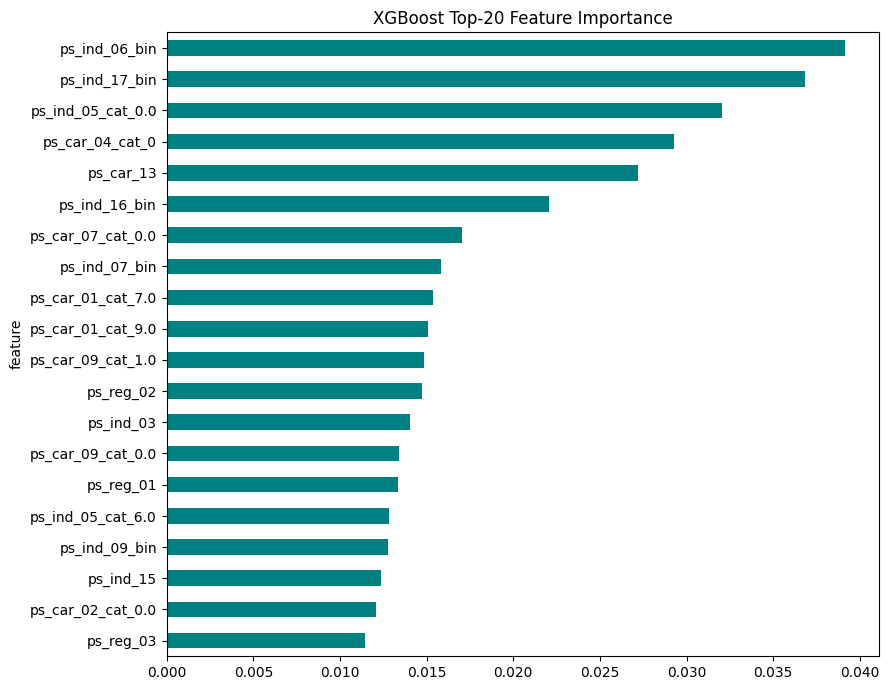

In [51]:
# XGBoost feature importance (top 20)
if xgb_model_last is not None:
    fi = xgb_model_last.feature_importances_
    feat_names = num_cols_ps + onehot_enc_ps.get_feature_names_out(cat_cols_filtered).tolist()
    fi_df = pd.DataFrame({'feature': feat_names, 'importance': fi})
    fi_df = fi_df.sort_values('importance', ascending=True).tail(20)
    fi_df.plot.barh(x='feature', y='importance', figsize=(9, 7),
                    legend=False, color='teal')
    plt.title('XGBoost Top-20 Feature Importance')
    plt.tight_layout()
    plt.show()


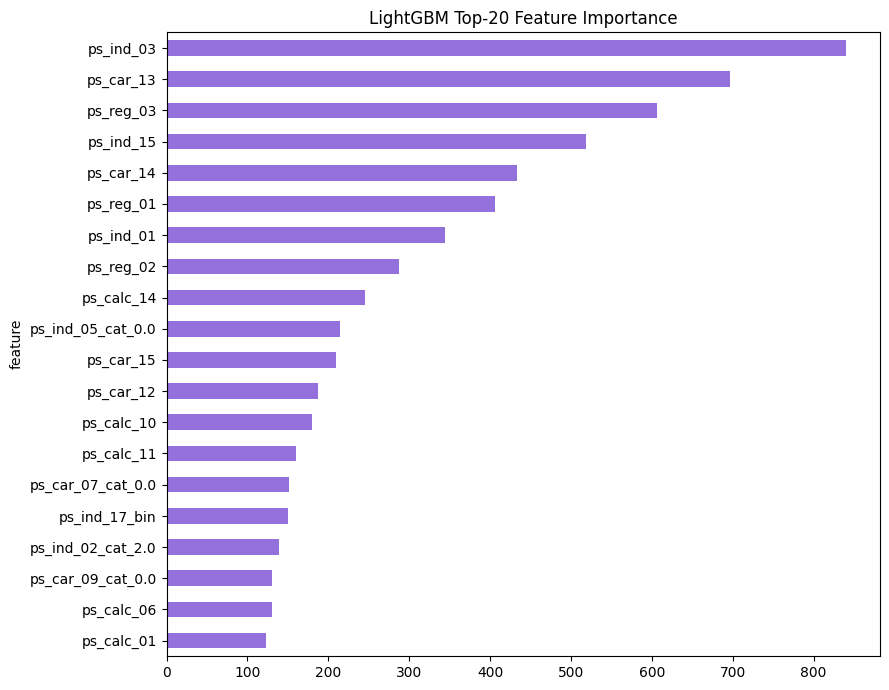

In [52]:
# LightGBM feature importance (top 20)
if lgb_model_last is not None:
    fi = lgb_model_last.feature_importances_
    feat_names = num_cols_ps + onehot_enc_ps.get_feature_names_out(cat_cols_filtered).tolist()
    fi_df = pd.DataFrame({'feature': feat_names, 'importance': fi})
    fi_df = fi_df.sort_values('importance', ascending=True).tail(20)
    fi_df.plot.barh(x='feature', y='importance', figsize=(9, 7),
                    legend=False, color='mediumpurple')
    plt.title('LightGBM Top-20 Feature Importance')
    plt.tight_layout()
    plt.show()


## Analysis & Conclusions

### Summary
We benchmarked five models on the Porto Seguro safe-driver prediction task.

- The dataset is **severely imbalanced** (~3.6 % positive), so **Normalized Gini**
  (= 2·AUC − 1) is the key competition metric.
- **LightGBM** with `is_unbalance=True` and **XGBoost** with `scale_pos_weight`
  are well-suited for this imbalanced setting.
- **FT-Transformer** uses learned categorical embeddings, which can capture
  non-linear interactions between the many categorical features.
- **Tabular ResNet** uses skip connections to learn deep tabular representations.
- **Random Forest** with `class_weight='balanced'` offers a strong tree baseline.

### Observations
- Gini scores on **synthetic** data are near 0 because the synthetic labels are
  random (independent of features). Real data results will differ substantially.
- The preprocessing pipeline — replacing -1 sentinels, mode/median imputation,
  OrdinalEncoding — mirrors common Kaggle solutions for this competition.
- 3-seed evaluation reduces variance in reported Gini.

### Next Steps
- Feature engineering: polynomial interactions among `ps_reg` features.
- Calibrated probability outputs for better threshold tuning.
- Stacking / blending of LightGBM + XGBoost predictions.
- SHAP analysis to understand which feature groups drive predictions.
